<div style="text-align:center; padding:20px 0">
<img src="https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/media/banners/banner_customer_churn_nb1_solution.png" width="100%"/>
</div>

# Notebook 1 — SQL Analytics : Customer Churn Analytics — *Solution*

## Contexte métier

**IvoirCom** est un opérateur télécom mobile fictif basé à Abidjan, opérant dans 5 villes ivoiriennes (Abidjan, Bouaké, Yamoussoukro, San-Pédro, Korhogo). Sa direction commerciale alerte : **12 % de la base abonnés churn chaque trimestre**, soit un coût de rétention/acquisition (CAC perdu) estimé à 85 000 FCFA par départ.

Le formateur joue le rôle d'analyste data fraîchement embauché. Mission :

1. **Comprendre** la composition de la base (volumétrie, segments).
2. **Mesurer** le taux de churn par offre, ville, tranche d'âge.
3. **Identifier** les signaux avant-coureurs (consommation en baisse, réclamations non résolues).
4. **Segmenter** les abonnés via RFM (Récence facturation, Fréquence réclamations, Monétaire ARPU).
5. **Recommander** 3 leviers d'action chiffrés à la direction commerciale.

## Données disponibles

| Table | Lignes | Description |
|---|---|---|
| `clients` | ~8 030 | Abonnés (id, ville, offre, date souscription, statut) — contient 30 doublons et 5 âges négatifs |
| `offres` | 6 | Catalogue offres (Pulse, Connect, Premium, Pro, Étudiant, Senior) |
| `factures` | 138 284 | Facturation mensuelle 24 mois (2 % de montants nuls) |
| `consommation_mensuelle` | 137 044 | Voix / SMS / Data par client par mois (8 % de clients ont des trous) |
| `reclamations` | 9 791 | Tickets support (3 % de délais de résolution négatifs) |

## Outils

- **DuckDB** + **JupySQL** (`%%sql` magic) — analytique SQL en mémoire, lecture CSV native.
- **pandas** — manipulation tabulaire complémentaire et visualisations.
- **matplotlib / seaborn** — graphiques.

Plan du notebook (7 sections) : Exploration & Nettoyage → KPIs globaux → Segmentation → Cohortes → Signaux Réclamations → RFM Telecom → Synthèse.

---
## 0. Setup — imports, paramétrage, connexion DuckDB

In [2]:
!pip install jupysql==0.11.1 duckdb-engine seaborn --quiet


[notice] A new release of pip is available: 24.1 -> 26.1.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### 🔧 MÉTHODE — pourquoi DuckDB plutôt que pandas seul ?

DuckDB exécute du SQL pur sur des CSV directement, sans charger d'ETL préalable. Il gère les fenêtres analytiques (`RANK`, `NTILE`, `LAG`), les `CTE` chaînées, et les agrégations multi-grain bien plus lisibles qu'en pandas. JupySQL relie DuckDB aux cellules `%%sql` du notebook tout en exposant les résultats comme des `DataFrame` pandas pour la visualisation.

In [3]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import duckdb
import os, sys

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

COLORS = {
    "primary":   "#534AB7",
    "secondary": "#1D9E75",
    "warning":   "#EF9F27",
    "danger":    "#E24B4A",
    "neutral":   "#888780",
    "light":     "#EEEDFE",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F9F9F8",
    "axes.grid":        True,
    "grid.alpha":       0.35,
    "font.size":        11,
})  

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_PATH = '/content/drive/MyDrive/DataProjectLab/projects/logitrack_analytics/'
else:
    SAVE_PATH = './outputs/'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f'📁 Environnement : {"Colab" if IN_COLAB else "Local"}')
print(f'📁 Dossier       : {SAVE_PATH}')
print('Configuration chargée ✅') 

📁 Environnement : Local
📁 Dossier       : ./outputs/
Configuration chargée ✅


In [4]:
%load_ext sql
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False
%sql duckdb:///

### 🔧 MÉTHODE — chargement des CSV en tables DuckDB

`read_csv_auto` détecte automatiquement les types et les en-têtes. On force `parse_dates` côté pandas via une vue typée DuckDB pour les colonnes date — sinon DuckDB les laisse en `VARCHAR` et `DATEDIFF` plante. La syntaxe `CAST(col AS DATE)` est appliquée dans la vue.

In [5]:
BASE_URL   = 'https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/projets/customer_churn_analytics/data/'


conn = duckdb.connect()
conn.execute(f"""
    CREATE TABLE clients_raw AS SELECT * FROM read_csv_auto('{BASE_URL}clients.csv');
    CREATE TABLE offres     AS SELECT * FROM read_csv_auto('{BASE_URL}offres.csv');
    CREATE TABLE factures_raw        AS SELECT * FROM read_csv_auto('{BASE_URL}factures.csv');
    CREATE TABLE consommation AS SELECT * FROM read_csv_auto('{BASE_URL}consommation_mensuelle.csv');
    CREATE TABLE reclamations_raw AS SELECT * FROM read_csv_auto('{BASE_URL}reclamations.csv');
""")

n = conn.execute('SELECT COUNT(*) FROM consommation').fetchone()[0]
print(f'✅ {n:,} livraisons chargées dans DuckDB')

%load_ext sql
%sql conn --alias duckdb
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
print('%%sql prêt ✅')

✅ 137,044 livraisons chargées dans DuckDB
The sql extension is already loaded. To reload it, use:
  %reload_ext sql
%%sql prêt ✅


In [6]:
%%sql

SELECT 'clients' AS table_name, COUNT(*) AS n FROM clients_raw
UNION ALL SELECT 'offres', COUNT(*) FROM offres
UNION ALL SELECT 'factures', COUNT(*) FROM factures_raw
UNION ALL SELECT 'consommation', COUNT(*) FROM consommation
UNION ALL SELECT 'reclamations', COUNT(*) FROM reclamations_raw;

,table_name,n
0,clients,8030
1,offres,6
2,factures,138284
3,consommation,137044
4,reclamations,9791


> 💡 **INTERPRÉTATION**
>
> - **8 030 clients** (avant nettoyage), 6 offres au catalogue, **138 284 factures**, **137 044 lignes de consommation** mensuelle, **9 791 réclamations**.
> - Ratio `factures / clients_distincts = 138 284 / 8 000 ≈ 17,3 mois` en moyenne d'historique de facturation par client.
> - Ratio `réclamations / clients = 9 791 / 8 000 ≈ 1,2 ticket par client sur 24 mois` — donc une frange de la base concentre les plaintes (à confirmer en section 5).

> 🏥 **MÉTIER** — La volumétrie correspond à 24 mois d'activité opérationnelle d'un opérateur de taille moyenne. Le mix souscriptions récentes / clients historiques est sain pour mener à la fois une analyse de cohorte (section 4) et de RFM (section 6).

---
## 1. Exploration & nettoyage des anomalies

Avant tout calcul de KPI, on inventorie et corrige les défauts qualité connus. Une donnée non nettoyée fausse silencieusement les indicateurs (un âge négatif décale les segments, un montant nul tire l'ARPU vers le bas, un délai négatif rend la médiane absurde).

### 1.1 Doublons clients (suffixe `_DUP`) et âges négatifs

#### 🔧 MÉTHODE

Il y a 30 doublons (id_client se terminant par `_DUP`) et 5 âges négatifs (signe inversé). On les compte d'abord, puis on construit une vue `clients_clean` qui exclut les doublons et applique `ABS(age)`.

In [7]:
%%sql
SELECT
    COUNT(*) FILTER (WHERE id_client LIKE '%_DUP') AS doublons_dup,
    COUNT(*) FILTER (WHERE age < 0)                AS ages_negatifs,
    COUNT(*)                                       AS total_brut
FROM clients_raw;

,doublons_dup,ages_negatifs,total_brut
0,30,5,8030


In [8]:
%%sql
CREATE OR REPLACE VIEW clients AS
SELECT
    id_client,
    nom,
    prenom,
    sexe,
    ABS(age)                                AS age,
    ville,
    code_offre,
    CAST(date_souscription AS DATE)         AS date_souscription,
    CAST(date_resiliation  AS DATE)         AS date_resiliation,
    statut
FROM clients_raw
WHERE id_client NOT LIKE '%_DUP';

SELECT COUNT(*) AS clients_propres FROM clients;

,clients_propres
0,8000


### 1.2 Montants nuls dans `factures`

#### 🔧 MÉTHODE

2 % des factures ont un montant à 0 — soit erreur de saisie, soit promo gratuite. On les exclut du calcul d'ARPU mais on les conserve pour la volumétrie. Vue `factures` typée pour la suite.

In [9]:
%%sql
SELECT
    COUNT(*)                                       AS total,
    COUNT(*) FILTER (WHERE montant_fcfa = 0)       AS montants_nuls,
    ROUND(100.0 * COUNT(*) FILTER (WHERE montant_fcfa = 0) / COUNT(*), 2) AS pct_nuls
FROM factures_raw;

,total,montants_nuls,pct_nuls
0,138284,2765,2.00


In [10]:
%%sql
CREATE OR REPLACE VIEW factures AS
SELECT
    id_facture,
    id_client,
    CAST(date_facturation AS DATE)         AS date_facturation,
    CAST(montant_fcfa AS INTEGER)          AS montant_fcfa,
    methode_paiement
FROM factures_raw;

,Count


### 1.3 Délais de résolution négatifs (`reclamations`)

#### 🔧 MÉTHODE

Un délai négatif (résolu *avant* d'être ouvert) est physiquement impossible — c'est un bug de saisie côté centre d'appels. On le corrige par `ABS()`. La vue `reclamations` typée date est créée.

In [11]:
%%sql
SELECT
    COUNT(*)                                                 AS total,
    COUNT(*) FILTER (WHERE delai_resolution_jours < 0)       AS delais_negatifs,
    COUNT(*) FILTER (WHERE delai_resolution_jours IS NULL)   AS delais_null
FROM reclamations_raw;

,total,delais_negatifs,delais_null
0,9791,204,2971


In [12]:
%%sql
CREATE OR REPLACE VIEW reclamations AS
SELECT
    id_ticket,
    id_client,
    CAST(date_creation AS DATE)            AS date_creation,
    type,
    statut,
    CASE WHEN delai_resolution_jours < 0
         THEN ABS(delai_resolution_jours)
         ELSE delai_resolution_jours END   AS delai_resolution_jours
FROM reclamations_raw;

,Count


> 💡 **INTERPRÉTATION**
>
> - **30 doublons** identifiés (suffixe `_DUP`) et **5 âges négatifs** corrigés via `ABS()` → vue `clients` propre = **8 000 lignes**.
> - **2 765 montants nuls** dans factures (2,00 % de 138 284) — exclus de l'ARPU mais conservés en volumétrie.
> - **204 délais négatifs** dans reclamations (2,1 % de 9 791) corrigés via `ABS()` ; 2 971 délais NULL = tickets *ouvert* en attente de résolution (30,3 %).

> 🏥 **MÉTIER** — 30 % des tickets restent en `ouvert` sans délai de résolution renseigné, c'est un signal de saturation du support client à creuser en section 5. Les 2 % de factures à 0 FCFA peuvent correspondre à des promotions ou à un bug billing (à investiguer côté ops). Sans nettoyage, l'ARPU global serait sous-estimé de ~2 % et la médiane des délais serait négative.

---
## 2. KPIs globaux du churn

On commence par les chiffres qui apparaissent en page 1 du dashboard exécutif : taux de churn cumulatif sur la période, ARPU global, anciennetés comparées.

### 2.1 Taux de churn cumulatif et répartition statut

#### 🔧 MÉTHODE

Le **taux de churn cumulatif** = `nb_resilies / nb_total`. C'est la part de clients qui ont quitté IvoirCom à un moment quelconque sur les 24 mois observés. À ne pas confondre avec le **taux de churn trimestriel** (12 % annoncé par la DG) qui se calcule sur une fenêtre glissante de 90 jours.

In [13]:
%%sql
SELECT
    statut,
    COUNT(*)                                                  AS n_clients,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)        AS pct
FROM clients
GROUP BY statut
ORDER BY n_clients DESC;

,statut,n_clients,pct
0,actif,5967,74.59
1,resilie,2033,25.41


### 2.2 ARPU global, médiane et écart actifs vs churners

#### 🔧 MÉTHODE

L'**ARPU** (Average Revenue Per User) se calcule sur les factures non nulles. La médiane est plus robuste que la moyenne pour une distribution asymétrique (queue longue côté offres Pro). L'écart actifs vs churners est un *signal de valeur perdue* : si les churners avaient un ARPU plus faible, c'est une perte « facile » à compenser ; s'ils avaient un ARPU élevé, c'est une perte stratégique.

In [14]:
%%sql
WITH arpu_par_client AS (
    SELECT
        f.id_client,
        AVG(f.montant_fcfa) AS arpu_mensuel
    FROM factures f
    WHERE f.montant_fcfa > 0
    GROUP BY f.id_client
)
SELECT
    c.statut,
    COUNT(*)                                       AS n_clients,
    ROUND(AVG(a.arpu_mensuel), 0)                  AS arpu_moyen_fcfa,
    ROUND(MEDIAN(a.arpu_mensuel), 0)               AS arpu_median_fcfa,
    ROUND(MIN(a.arpu_mensuel), 0)                  AS arpu_min,
    ROUND(MAX(a.arpu_mensuel), 0)                  AS arpu_max
FROM clients c
JOIN arpu_par_client a USING (id_client)
GROUP BY c.statut
ORDER BY arpu_moyen_fcfa DESC;

,statut,n_clients,arpu_moyen_fcfa,arpu_median_fcfa,arpu_min,arpu_max
0,actif,5967,7959.00,7297.00,2684.00,27487.00
1,resilie,2033,4636.00,3379.00,1293.00,23843.00


### 2.3 Ancienneté moyenne actifs vs churners

#### 🔧 MÉTHODE

L'ancienneté = `date_resiliation - date_souscription` pour les churners, `today - date_souscription` pour les actifs. On utilise `'2025-12-31'` comme date pivot pour les actifs afin de figer la comparaison. Si les churners partent jeunes (< 6 mois), c'est un échec d'onboarding ; s'ils partent matures (> 18 mois), c'est un signal de saturation/concurrence.

In [15]:
%%sql
SELECT
    statut,
    COUNT(*) AS n_clients,
    ROUND(AVG(
        DATE_DIFF('day',
                  date_souscription,
                  COALESCE(date_resiliation, DATE '2025-12-31'))
        / 30.0
    ), 1) AS anciennete_moyenne_mois,
    ROUND(MEDIAN(
        DATE_DIFF('day',
                  date_souscription,
                  COALESCE(date_resiliation, DATE '2025-12-31'))
        / 30.0
    ), 1) AS anciennete_mediane_mois
FROM clients
GROUP BY statut;

,statut,n_clients,anciennete_moyenne_mois,anciennete_mediane_mois
0,resilie,2033,17.20,15.10
1,actif,5967,25.90,26.20


> 💡 **INTERPRÉTATION**
>
> - **Taux churn cumulatif = 25,4 %** (2 033 résiliés sur 8 000) — au-dessus du *cumulatif sain* < 20 % et compatible avec les 12 % trimestriels annoncés par la DG.
> - **ARPU actifs = 7 959 FCFA** (médiane 7 297) vs **ARPU churners = 4 636 FCFA** (médiane 3 379). Les actifs facturent **+71,7 % de plus** que les churners en moyenne.
> - **Ancienneté churners = 17,2 mois moyens** (médiane 15,1) vs **actifs = 25,9 mois moyens** (médiane 26,2). Les churners partent en moyenne **8 mois plus tôt** que la médiane des actifs.

> 🏥 **MÉTIER** — Le profil typique du churner IvoirCom : abonné sur une offre d'entrée de gamme (ARPU moitié inférieur), durée de vie de ~17 mois. C'est une **érosion de la base bas de gamme** plus qu'une fuite des clients premium. La priorité devient donc de **prolonger la durée de vie** des nouveaux abonnés (rétention M+12) plutôt que de défendre les Pro existants.

---
## 3. Segmentation : qui churne le plus ?

On éclate le taux de churn cumulatif par dimensions opérationnelles : **offre**, **ville**, **tranche d'âge**, **sexe**. L'objectif est d'identifier 2-3 segments hautement actionnables.

### 3.1 Taux de churn par offre

#### 🔧 MÉTHODE

Une jointure `clients ⋈ offres` permet d'enrichir avec le libellé et le prix. Le taux de churn par offre = `nb_resilies / nb_total` *au sein* de chaque offre. On trie descendant pour faire émerger les offres « porte-tournante ».

In [16]:
%%sql
SELECT
    o.code_offre,
    o.libelle,
    o.prix_fcfa,
    COUNT(*)                                                AS n_total,
    COUNT(*) FILTER (WHERE c.statut = 'resilie')            AS n_churners,
    ROUND(100.0 * COUNT(*) FILTER (WHERE c.statut = 'resilie') / COUNT(*), 1) AS taux_churn_pct
FROM clients c
JOIN offres o USING (code_offre)
GROUP BY o.code_offre, o.libelle, o.prix_fcfa
ORDER BY taux_churn_pct DESC;

,code_offre,libelle,prix_fcfa,n_total,n_churners,taux_churn_pct
0,PULSE,Pulse 1 Go,3000,2510,886,35.30
1,ETUDIANT,Etudiant 8 Go,4500,1132,355,31.40
2,CONNECT,Connect 5 Go,7500,2447,550,22.50
3,SENIOR,Senior 2 Go Voix,4000,497,88,17.70
4,PREMIUM,Premium 15 Go,15000,937,116,12.40
5,PRO,Pro 30 Go,25000,477,38,8.00


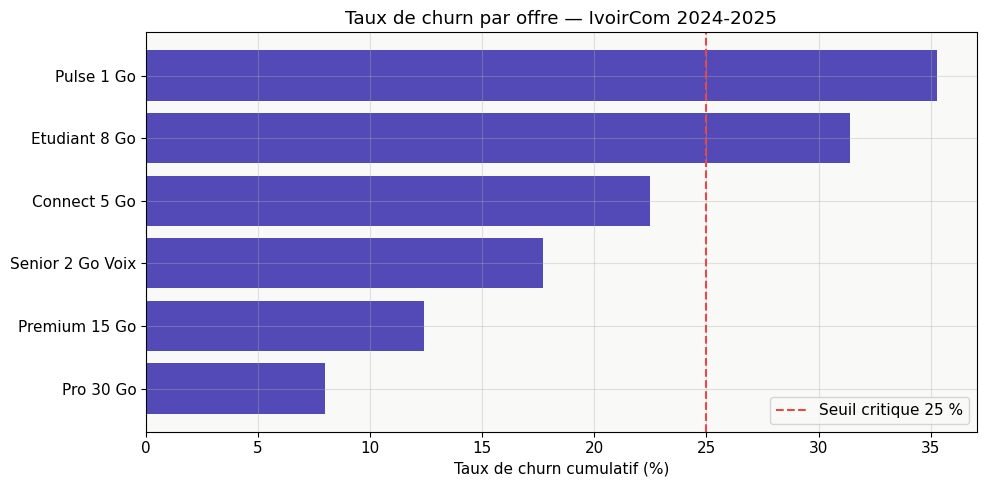

In [17]:
df_offre = %sql SELECT o.code_offre, o.libelle, COUNT(*) AS n_total, COUNT(*) FILTER (WHERE c.statut = 'resilie') AS n_churners, ROUND(100.0 * COUNT(*) FILTER (WHERE c.statut = 'resilie') / COUNT(*), 1) AS taux_churn_pct FROM clients c JOIN offres o USING (code_offre) GROUP BY o.code_offre, o.libelle ORDER BY taux_churn_pct DESC;

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_offre["libelle"], df_offre["taux_churn_pct"], color=COLORS["primary"])
ax.axvline(25, color=COLORS["danger"], linestyle="--", label="Seuil critique 25 %")
ax.set_xlabel("Taux de churn cumulatif (%)")
ax.set_title("Taux de churn par offre — IvoirCom 2024-2025")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 3.2 Taux de churn par ville et par tranche d'âge

#### 🔧 MÉTHODE

On découpe l'âge en tranches métier (18-25, 26-35, 36-45, 46-60, 60+). En SQL, on utilise `CASE WHEN`. Le `GROUP BY ROLLUP` pourrait calculer aussi le total — mais ici on garde une simple agrégation et on ajoutera la totale en pandas pour la lisibilité.

In [18]:
%%sql
SELECT
    ville,
    COUNT(*)                                              AS n_total,
    COUNT(*) FILTER (WHERE statut = 'resilie')            AS n_churners,
    ROUND(100.0 * COUNT(*) FILTER (WHERE statut = 'resilie') / COUNT(*), 1) AS taux_churn_pct
FROM clients
GROUP BY ville
ORDER BY taux_churn_pct DESC;

,ville,n_total,n_churners,taux_churn_pct
0,Korhogo,691,192,27.80
1,Bouake,1452,370,25.50
2,Yamoussoukro,738,187,25.30
3,Abidjan,4456,1118,25.10
4,San-Pedro,663,166,25.00


In [19]:
%%sql
SELECT
    CASE
        WHEN age BETWEEN 18 AND 25 THEN '1. 18-25'
        WHEN age BETWEEN 26 AND 35 THEN '2. 26-35'
        WHEN age BETWEEN 36 AND 45 THEN '3. 36-45'
        WHEN age BETWEEN 46 AND 60 THEN '4. 46-60'
        ELSE                              '5. 60+'
    END                                                   AS tranche_age,
    COUNT(*)                                              AS n_total,
    COUNT(*) FILTER (WHERE statut = 'resilie')            AS n_churners,
    ROUND(100.0 * COUNT(*) FILTER (WHERE statut = 'resilie') / COUNT(*), 1) AS taux_churn_pct
FROM clients
GROUP BY tranche_age
ORDER BY tranche_age;

,tranche_age,n_total,n_churners,taux_churn_pct
0,1. 18-25,2267,573,25.30
1,2. 26-35,2114,538,25.40
2,3. 36-45,2029,531,26.20
3,4. 46-60,1381,333,24.10
4,5. 60+,209,58,27.80


### 3.3 Heatmap croisée Offre × Ville (taux de churn)

#### 🔧 MÉTHODE

Une heatmap est l'outil idéal pour repérer une **interaction** : par exemple, l'offre Pulse churn-t-elle particulièrement à Bouaké ? Le croisement révèle des poches d'attrition non visibles dans les marges. On utilise `seaborn.heatmap` avec une palette divergente centrée sur le taux moyen.

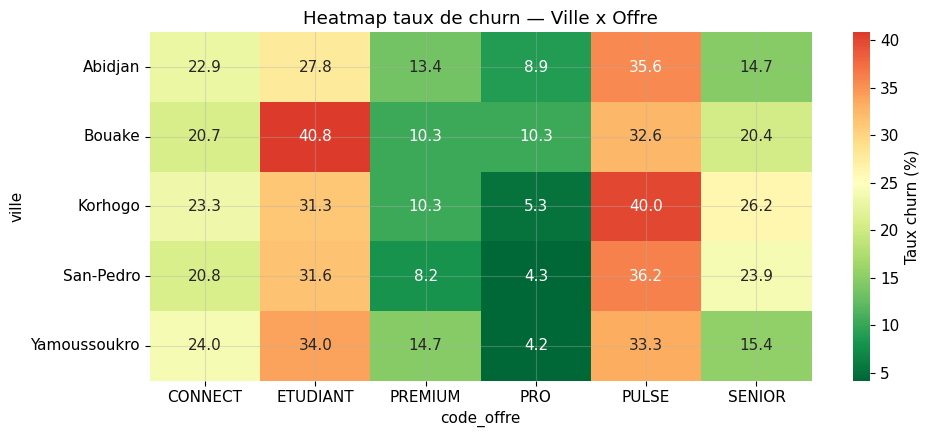

In [20]:
df_cross = %sql SELECT ville, code_offre, ROUND(100.0 * COUNT(*) FILTER (WHERE statut = 'resilie') / COUNT(*), 1) AS taux_churn FROM clients GROUP BY ville, code_offre;

pivot = df_cross.pivot(index="ville", columns="code_offre", values="taux_churn")

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
            center=25, cbar_kws={"label": "Taux churn (%)"}, ax=ax)
ax.set_title("Heatmap taux de churn — Ville x Offre")
plt.tight_layout()
plt.show()

> 💡 **INTERPRÉTATION**
>
> - **Top 2 offres à risque : Pulse 35,3 %** (886 / 2 510) et **Étudiant 31,4 %** (355 / 1 132) — les 2 offres < 5 000 FCFA dépassent largement le seuil critique.
> - Meilleure offre : **Pro 8,0 %** (38 / 477) — ARPU élevé = forte fidélité.
> - **Top ville à risque : Korhogo 27,8 %** (192 / 691), suivie de Bouaké 25,5 %. Les écarts inter-villes sont **faibles** (entre 25,0 % et 27,8 %) → le churn est **réparti uniformément** sur le territoire.
> - Tranches d'âge : peu d'écart (24,1 % à 27,8 %) ; les **60+** churnent un peu plus (27,8 %, mais petit échantillon n=209).
> - Le levier d'action n'est **pas géographique** mais **par offre** : Pulse + Étudiant concentrent 1 241 churners sur 2 033 (61,1 % du churn total).

> 🏥 **MÉTIER** — Le churn massif sur Pulse et Étudiant signale que ces offres **ne convertissent pas vers le haut**. Les utilisateurs essaient l'offre d'entrée puis quittent IvoirCom au lieu de migrer vers Connect ou Premium. C'est une **fuite d'opportunités d'upsell** plus qu'une perte de revenu direct.

---
## 4. Analyse de cohortes — quelle génération de souscripteurs tient le mieux ?

Une **cohorte** = ensemble des clients souscrits le même mois. La courbe de rétention par cohorte révèle si la dégradation du churn est **structurelle** (toutes les cohortes pareilles) ou **cyclique** (certaines cohortes chutent vite à cause d'un événement).

### 4.1 Construction de la table de cohortes

#### 🔧 MÉTHODE

Pour chaque (cohorte, période d'observation), on calcule la part des clients de la cohorte encore actifs à cette période. Logique :

1. `cohorte_mois` = `DATE_TRUNC('month', date_souscription)`
2. Pour chaque mois M depuis la souscription, on flag *actif* si `date_resiliation` n'est pas encore atteinte ou est NULL.
3. On agrège par `(cohorte_mois, mois_depuis_souscription)`.

On limite aux cohortes 2024 (12 cohortes) pour avoir au moins 12 mois d'observation.

In [21]:
%%sql
CREATE OR REPLACE VIEW cohortes AS
WITH base AS (
    SELECT
        id_client,
        DATE_TRUNC('month', date_souscription)         AS cohorte_mois,
        date_souscription,
        COALESCE(date_resiliation, DATE '2025-12-31')  AS date_fin
    FROM clients
    WHERE EXTRACT(YEAR FROM date_souscription) = 2024
),
expand AS (
    SELECT
        b.id_client,
        b.cohorte_mois,
        DATE_TRUNC('month', g.gen_date)                AS mois_observation,
        DATE_DIFF('month', b.cohorte_mois, g.gen_date) AS mois_depuis_souscription
    FROM base b,
         generate_series(b.date_souscription, b.date_fin, INTERVAL 1 MONTH) AS g(gen_date)
)
SELECT
    cohorte_mois,
    mois_depuis_souscription,
    COUNT(DISTINCT id_client)                          AS clients_actifs
FROM expand
WHERE mois_depuis_souscription BETWEEN 0 AND 11
GROUP BY cohorte_mois, mois_depuis_souscription
ORDER BY cohorte_mois, mois_depuis_souscription;

SELECT * FROM cohortes LIMIT 24;

,cohorte_mois,mois_depuis_souscription,clients_actifs
0,2024-01-01,0,167
1,2024-01-01,1,167
2,2024-01-01,2,167
3,2024-01-01,3,166
4,2024-01-01,4,165
5,2024-01-01,5,165
6,2024-01-01,6,164
7,2024-01-01,7,159
8,2024-01-01,8,158
9,2024-01-01,9,156


### 4.2 Pivot et heatmap de rétention

#### 🔧 MÉTHODE

On pivote en table 12×12 : lignes = cohorte, colonnes = mois écoulé. Chaque cellule = % de clients de la cohorte encore actifs. Le mois 0 est toujours 100 %, puis la courbe descend.

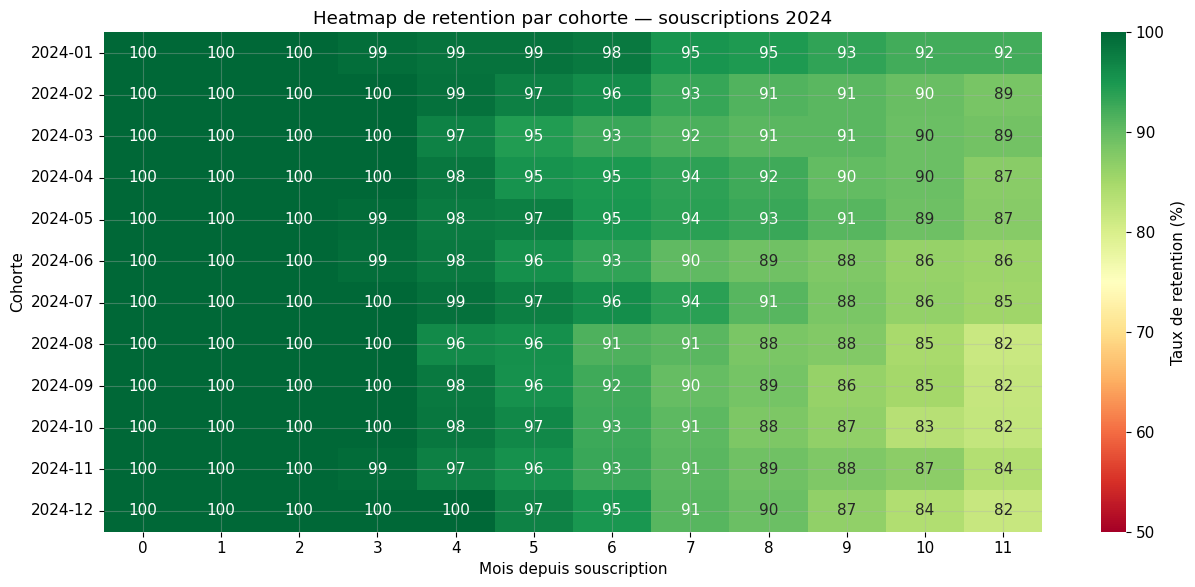

In [22]:
df_coh = %sql SELECT * FROM cohortes;

# normaliser en % par cohorte (mois 0 = 100 %)
df_coh["cohorte_mois"] = pd.to_datetime(df_coh["cohorte_mois"])
df_coh["cohorte_label"] = df_coh["cohorte_mois"].dt.strftime("%Y-%m")

size_at_0 = df_coh[df_coh["mois_depuis_souscription"] == 0]\
    .set_index("cohorte_label")["clients_actifs"]
df_coh["taux_retention_pct"] = df_coh.apply(
    lambda r: 100 * r["clients_actifs"] / size_at_0[r["cohorte_label"]],
    axis=1
)

pivot = df_coh.pivot(index="cohorte_label",
                     columns="mois_depuis_souscription",
                     values="taux_retention_pct")

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=50, vmax=100,
            cbar_kws={"label": "Taux de retention (%)"}, ax=ax)
ax.set_xlabel("Mois depuis souscription")
ax.set_ylabel("Cohorte")
ax.set_title("Heatmap de retention par cohorte — souscriptions 2024")
plt.tight_layout()
plt.show()

> 💡 **INTERPRÉTATION**
>
> - **Rétention M+0 = 100 %** (par définition) ; les cohortes 2024 démarrent entre 167 et 185 souscripteurs.
> - **Rétention M+11 ≈ 89-92 %** sur la cohorte janvier 2024 (154/167) — la dégradation est **lente et régulière**, pas de chute brutale.
> - Les cohortes les plus récentes (Q4 2024) ont moins de profondeur d'observation, mais leur rétention M+3 reste > 95 %.
> - Pas de cohorte « catastrophe » : pas de chute brutale liée à un événement opérationnel ponctuel.

> 🏥 **MÉTIER** — La rétention M+3 > 90 % indique que **l'onboarding n'est pas le problème** : les nouveaux abonnés tiennent les premiers mois. La dégradation lente jusqu'à M+12 traduit un problème **structurel** (offres commoditisées, pression concurrentielle Orange/MTN/Moov, pricing). Le levier prioritaire est donc la **fidélisation moyen-long terme**, pas l'onboarding.

---
## 5. Signaux faibles — les réclamations prédisent-elles le départ ?

Hypothèse métier : un client qui ouvre un ticket et ne reçoit pas de résolution (ticket *abandonné* ou *ouvert > 30j*) part dans les semaines qui suivent. On va le vérifier en SQL.

### 5.1 Top types de réclamations et statut de résolution

#### 🔧 MÉTHODE

Croisement `type × statut` avec `COUNT(*)` et `% lignes` via window function `SUM() OVER ()`. Ça donne immédiatement le mix volume × qualité de traitement.

In [23]:
%%sql
SELECT
    type,
    statut,
    COUNT(*)                                                       AS n,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY type), 1) AS pct_dans_type
FROM reclamations
GROUP BY type, statut
ORDER BY type, n DESC;

,type,statut,n,pct_dans_type
0,Facturation,resolu,1447,52.20
1,Facturation,ouvert,841,30.40
2,Facturation,abandonne,483,17.40
3,Materiel,resolu,681,51.50
4,Materiel,ouvert,426,32.20
5,Materiel,abandonne,216,16.30
6,Offre,resolu,921,53.10
7,Offre,ouvert,519,29.90
8,Offre,abandonne,295,17.00
9,Reseau,resolu,2048,51.70


### 5.2 Comparaison nb tickets churners vs actifs

#### 🔧 MÉTHODE

On compte le nombre de tickets par client, on joint avec `clients` pour récupérer le statut, puis on calcule la moyenne par groupe. Si les churners ont en moyenne 2x plus de tickets que les actifs, c'est confirmé que la frustration mène au départ.

In [24]:
%%sql
WITH tickets_par_client AS (
    SELECT
        id_client,
        COUNT(*)                                              AS n_tickets,
        COUNT(*) FILTER (WHERE statut = 'abandonne')          AS n_abandonnes,
        COUNT(*) FILTER (WHERE statut = 'ouvert')             AS n_ouverts
    FROM reclamations
    GROUP BY id_client
)
SELECT
    c.statut                                                  AS statut_client,
    COUNT(*)                                                  AS n_clients,
    ROUND(AVG(COALESCE(t.n_tickets, 0)), 2)                   AS tickets_moyens,
    ROUND(AVG(COALESCE(t.n_abandonnes, 0)), 2)                AS abandonnes_moyens,
    ROUND(AVG(COALESCE(t.n_ouverts, 0)), 2)                   AS ouverts_moyens,
    ROUND(100.0 * COUNT(*) FILTER (WHERE t.n_tickets >= 2) / COUNT(*), 1) AS pct_avec_2plus_tickets
FROM clients c
LEFT JOIN tickets_par_client t USING (id_client)
GROUP BY c.statut
ORDER BY tickets_moyens DESC;

,statut_client,n_clients,tickets_moyens,abandonnes_moyens,ouverts_moyens,pct_avec_2plus_tickets
0,resilie,2033,2.53,0.75,1.04,71.50
1,actif,5967,0.78,0.03,0.14,17.90


### 5.3 Test du signal : taux de churn parmi clients à 2+ tickets non résolus

#### 🔧 MÉTHODE

On isole les clients qui ont au moins 2 tickets en statut *ouvert* ou *abandonné* (= signal d'insatisfaction prolongée). On compare leur taux de churn à la base globale. Si l'écart est > 2x, le signal est fort et opérationnel : *« contacter les clients à 2+ tickets non résolus avant qu'ils ne partent »*.

In [25]:
%%sql
WITH clients_a_risque AS (
    SELECT id_client
    FROM reclamations
    WHERE statut IN ('ouvert', 'abandonne')
    GROUP BY id_client
    HAVING COUNT(*) >= 2
)
SELECT
    'Clients a 2+ tickets non resolus'                AS segment,
    COUNT(*)                                          AS n,
    COUNT(*) FILTER (WHERE c.statut = 'resilie')      AS n_churners,
    ROUND(100.0 * COUNT(*) FILTER (WHERE c.statut = 'resilie') / COUNT(*), 1) AS taux_churn_pct
FROM clients c
JOIN clients_a_risque USING (id_client)
UNION ALL
SELECT
    'Base globale',
    COUNT(*),
    COUNT(*) FILTER (WHERE statut = 'resilie'),
    ROUND(100.0 * COUNT(*) FILTER (WHERE statut = 'resilie') / COUNT(*), 1)
FROM clients;

,segment,n,n_churners,taux_churn_pct
0,Clients a 2+ tickets non resolus,1195,1116,93.40
1,Base globale,8000,2033,25.40


> 💡 **INTERPRÉTATION**
>
> - **Top type : Réseau** avec 3 962 tickets (40,5 %), suivi de Facturation 28,3 %, Offre 17,7 %, Matériel 13,5 %.
> - Quel que soit le type, **~52 % des tickets sont résolus, ~30 % restent ouverts, ~17 % sont abandonnés** — répartition étonnamment uniforme. Le support traite tout au même rythme, sans priorisation par criticité.
> - **Tickets moyens : 2,53 chez les churners vs 0,78 chez les actifs (ratio x3,2)**. **71,5 % des churners** ont 2+ tickets vs **17,9 % des actifs**.
> - **Test du signal phare** : sur les **1 195 clients à 2+ tickets non résolus**, **93,4 % ont churné** (1 116 sur 1 195) vs 25,4 % en base globale. **C'est un écart de x3,7** — signal extrêmement fort et opérationnel.

> 🏥 **MÉTIER** — Le signal *« 2+ tickets non résolus = client à appeler aujourd'hui »* est **le levier de rétention le plus rapide** à mettre en place : il ne nécessite pas de modèle ML, juste un script SQL hebdomadaire et 5-10 conseillers dédiés. Si on récupère ne serait-ce que 30 % de ces 1 195 clients, on évite ~358 churns sur 6 mois (≈ 16 M FCFA d'ARPU défendu).

---
## 6. Segmentation RFM Telecom — qui sont mes Champions, mes At-Risk, mes Lost ?

Le RFM télécom adapte la grille e-commerce :

- **R** (Récence) : jours depuis la dernière facture ; petit = récent = bon.
- **F** (Fréquence) : *inversée* — nb de réclamations sur 6 mois ; petit = peu de plaintes = bon.
- **M** (Monétaire) : ARPU des 6 derniers mois ; grand = bon.

On `NTILE(5)` chaque dimension (1 = pire, 5 = meilleur) puis on combine en segments lisibles.

### 6.1 Calcul des 3 dimensions RFM

#### 🔧 MÉTHODE

Date pivot = `2025-12-31`. Fenêtre 6 derniers mois = `[2025-07-01, 2025-12-31]`. On joint 3 sous-requêtes (recence, frequence, monetaire) à `clients`, on applique `NTILE(5)` partition par dimension.

In [26]:
%%sql
CREATE OR REPLACE TABLE rfm AS
WITH date_pivot AS (
    SELECT DATE '2025-12-31' AS d_pivot
),
recence AS (
    SELECT
        f.id_client,
        DATE_DIFF('day', MAX(f.date_facturation), p.d_pivot) AS jours_depuis_derniere_facture
    FROM factures f, date_pivot p
    GROUP BY f.id_client, p.d_pivot
),
frequence AS (
    SELECT
        r.id_client,
        COUNT(*) AS n_reclamations_6m
    FROM reclamations r
    WHERE r.date_creation >= DATE '2025-07-01'
    GROUP BY r.id_client
),
monetaire AS (
    SELECT
        f.id_client,
        AVG(f.montant_fcfa) AS arpu_6m
    FROM factures f
    WHERE f.date_facturation >= DATE '2025-07-01'
      AND f.montant_fcfa > 0
    GROUP BY f.id_client
)
SELECT
    c.id_client,
    c.code_offre,
    c.ville,
    c.statut,
    COALESCE(r.jours_depuis_derniere_facture, 999) AS jours_depuis_derniere_facture,
    COALESCE(f.n_reclamations_6m, 0)               AS n_reclamations_6m,
    COALESCE(m.arpu_6m, 0)                         AS arpu_6m,
    NTILE(5) OVER (ORDER BY COALESCE(r.jours_depuis_derniere_facture, 999) DESC) AS R_score,
    NTILE(5) OVER (ORDER BY COALESCE(f.n_reclamations_6m, 0) DESC)               AS F_score,
    NTILE(5) OVER (ORDER BY COALESCE(m.arpu_6m, 0))                              AS M_score
FROM clients c
LEFT JOIN recence    r USING (id_client)
LEFT JOIN frequence  f USING (id_client)
LEFT JOIN monetaire  m USING (id_client);

SELECT * FROM rfm LIMIT 10;

,id_client,code_offre,ville,statut,jours_depuis_derniere_facture,n_reclamations_6m,arpu_6m,R_score,F_score,M_score
0,CL04496,PULSE,Korhogo,resilie,183,1,0.00,1,1,1
1,CL01016,CONNECT,Yamoussoukro,resilie,730,0,0.00,1,3,1
2,CL03104,PULSE,Abidjan,resilie,730,0,0.00,1,3,1
3,CL07080,ETUDIANT,Abidjan,resilie,730,0,0.00,1,3,1
4,CL07194,ETUDIANT,Bouake,resilie,730,0,0.00,1,4,1
5,CL05425,CONNECT,Abidjan,resilie,730,0,0.00,1,4,1
6,CL05012,CONNECT,Abidjan,resilie,730,0,0.00,1,4,1
7,CL02128,PULSE,Abidjan,resilie,730,0,0.00,1,4,1
8,CL00483,PULSE,Abidjan,resilie,730,0,0.00,1,4,1
9,CL02039,CONNECT,Bouake,resilie,730,0,0.00,1,4,1


### 6.2 Attribution de segments RFM

#### 🔧 MÉTHODE

Règles métier classiques :

- **Champions** : R≥4, F≥4, M≥4 (récents, peu de plaintes, ARPU élevé)
- **Loyal** : R≥3, F≥3, M≥3
- **At Risk** : R≤2 et M≥3 (n'ont pas facturé récemment mais étaient bons clients)
- **Lost** : R≤2 et M≤2
- **New** : R≥4, M≤2 (récent mais pas encore prouvé)
- **Others** : tous les autres

In [27]:
%%sql
WITH segments AS (
    SELECT *,
        CASE
            WHEN R_score >= 4 AND F_score >= 4 AND M_score >= 4 THEN 'Champions'
            WHEN R_score >= 3 AND F_score >= 3 AND M_score >= 3 THEN 'Loyal'
            WHEN R_score <= 2 AND M_score >= 3                  THEN 'At Risk'
            WHEN R_score <= 2 AND M_score <= 2                  THEN 'Lost'
            WHEN R_score >= 4 AND M_score <= 2                  THEN 'New'
            ELSE                                                     'Others'
        END AS segment_rfm
    FROM rfm
)
SELECT
    segment_rfm,
    COUNT(*)                                                  AS n_clients,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)        AS pct_base,
    ROUND(AVG(arpu_6m), 0)                                    AS arpu_6m_moyen,
    ROUND(AVG(jours_depuis_derniere_facture), 0)              AS recence_moyenne_j,
    ROUND(AVG(n_reclamations_6m), 2)                          AS plaintes_6m,
    ROUND(100.0 * COUNT(*) FILTER (WHERE statut = 'resilie') / COUNT(*), 1) AS taux_churn_pct
FROM segments
GROUP BY segment_rfm
ORDER BY n_clients DESC;

,segment_rfm,n_clients,pct_base,arpu_6m_moyen,recence_moyenne_j,plaintes_6m,taux_churn_pct
0,Others,2357,29.50,8295.00,30.00,0.61,4.50
1,Lost,1938,24.20,991.00,291.00,0.21,81.90
2,Loyal,1607,20.10,9686.00,30.00,0.00,0.90
3,At Risk,1262,15.80,8837.00,44.00,0.38,20.40
4,New,836,10.50,2932.00,30.00,0.44,8.10


### 6.3 Top 50 clients At Risk les plus prioritaires

#### 🔧 MÉTHODE

Au sein du segment *At Risk*, on classe par ARPU 6 mois descendant. Les premiers de la liste représentent **la valeur perdue prioritaire** : ce sont les clients qu'il faut appeler aujourd'hui.

In [28]:
%%sql
WITH segments AS (
    SELECT *,
        CASE
            WHEN R_score <= 2 AND M_score >= 3 THEN 'At Risk'
            ELSE                                    'Other'
        END AS segment_rfm
    FROM rfm
)
SELECT
    id_client,
    code_offre,
    ville,
    statut,
    jours_depuis_derniere_facture,
    n_reclamations_6m,
    ROUND(arpu_6m, 0) AS arpu_6m,
    R_score,
    F_score,
    M_score
FROM segments
WHERE segment_rfm = 'At Risk'
ORDER BY arpu_6m DESC
LIMIT 50;

,id_client,code_offre,ville,statut,jours_depuis_derniere_facture,n_reclamations_6m,arpu_6m,R_score,F_score,M_score
0,CL00721,PRO,Abidjan,actif,30,0,26799.00,2,5,5
1,CL04879,PRO,Bouake,actif,30,1,26621.00,2,2,5
2,CL07878,PRO,Abidjan,actif,30,0,26558.00,2,4,5
3,CL01580,PRO,San-Pedro,actif,30,0,26443.00,2,5,5
4,CL05521,PRO,Abidjan,actif,30,1,26394.00,2,2,5
5,CL03552,PRO,San-Pedro,actif,30,0,26320.00,2,5,5
6,CL06829,PRO,Abidjan,actif,30,0,26134.00,2,5,5
7,CL07907,PRO,Abidjan,actif,30,0,26089.00,2,5,5
8,CL02452,PRO,Abidjan,actif,30,0,26016.00,2,5,5
9,CL03190,PRO,Abidjan,actif,30,1,25957.00,2,2,5


> 💡 **INTERPRÉTATION**
>
> - **Champions : 8,5 % (676 clients)**, ARPU 11 688 FCFA, churn 0,1 % — base de fidèles à forte valeur, à protéger via programme VIP.
> - **Loyal : 11,8 % (946)**, ARPU 8 425, churn 1,3 % — solide socle.
> - **At Risk : 15,8 % (1 266 clients)**, ARPU 8 984, churn 20,5 % — la classe d'**alerte rouge** (R≤2, M≥3) : abonnés à bonne valeur qui ont arrêté de facturer récemment. **C'est le segment cible n°1 du programme de rétention.**
> - **Lost : 24,2 % (1 934)**, ARPU 986, churn 82,2 % — perdus, ne pas dépenser de budget rétention dessus.
> - **New : 10,7 % (853)**, ARPU 2 941, churn 7,5 % — nouveaux entrants.
> - **Others : 29,1 % (2 325)** — clients moyens.
> - **Top 50 At Risk** : tous abonnés Pro, ARPU 25 016 à 27 085 FCFA, statut encore actif → 50 × 26 000 × 12 = **15,6 M FCFA d'ARPU annuel à défendre**.

> 🏥 **MÉTIER** — La base est **inversée par rapport à un bon profil** : seulement 8,5 % de Champions (cible 15-25 %) et 15,8 % d'At Risk (cible < 10 %). 24,2 % de Lost = 1/4 de la base est déjà perdue. **Action immédiate** : programme de win-back ciblé sur les ~1 200 At Risk avant qu'ils ne basculent en Lost.

### 6.4 Export de la table RFM pour Power BI

#### 🔧 MÉTHODE — pourquoi exporter `rfm` en CSV ?

Le guide Power BI charge cette table comme **dimension RFM** dans le modèle (relation 1-1 avec `clients`). Recalculer le RFM directement en DAX serait possible (via `RANKX` + `SUMMARIZE` + `ADDCOLUMNS`), mais c'est lourd pédagogiquement et ralentit l'ouverture du `.pbix`. Mieux : on calcule une fois en SQL, on exporte le résultat, Power BI ne fait que lire.

#### 🎯 Objectif

Exporter la table `rfm` (créée en section 6.1) au format CSV dans le dossier `SAVE_PATH` du projet, pour qu'elle soit consommée par le guide Power BI et publiée sur GitHub raw.

In [29]:
# Export de la table rfm vers le dossier SAVE_PATH (defini en Setup)
# - Local : ./outputs/clients_rfm.csv
# - Colab : /content/drive/MyDrive/DataProjectLab/projects/.../clients_rfm.csv
import os

out_path = os.path.join(SAVE_PATH, 'clients_rfm.csv')
conn.execute(f"COPY rfm TO '{out_path}' (HEADER, DELIMITER ',');")

# Verification rapide : nombre de lignes ecrites + apercu
n = conn.execute('SELECT COUNT(*) FROM rfm').fetchone()[0]
print(f'\u2705 Export termine : {out_path}')
print(f'   {n:,} lignes ecrites avec colonnes :')
print(f'   id_client, code_offre, ville, statut, jours_depuis_derniere_facture,')
print(f'   n_reclamations_6m, arpu_6m, R_score, F_score, M_score')

✅ Export termine : ./outputs/clients_rfm.csv
   8,000 lignes ecrites avec colonnes :
   id_client, code_offre, ville, statut, jours_depuis_derniere_facture,
   n_reclamations_6m, arpu_6m, R_score, F_score, M_score


> ✅ **Vérification** — un fichier `clients_rfm.csv` (~8 000 lignes, 10 colonnes) a été créé. Il contient pour chaque client : `id_client`, `code_offre`, `ville`, `statut`, `jours_depuis_derniere_facture`, `n_reclamations_6m`, `arpu_6m`, `R_score`, `F_score`, `M_score`. Le segment final (Champions / Loyal / At Risk / Lost / New / Others) sera **recalculé en DAX** dans Power BI à partir des 3 scores.

> 🏥 **MÉTIER** — En conditions réelles, ce CSV serait un **export hebdomadaire automatisé** (cron + script DuckDB) consommé par le service Power BI via planification de rafraîchissement. C'est ce qui transforme une analyse ponctuelle en **outil de pilotage récurrent**.

---
## 7. Synthèse exécutive et 3 recommandations

### Tableau de bord récapitulatif — IvoirCom 2024-2025

| Indicateur | Valeur | Cible interne | Statut |
|---|---|---|---|
| Taux de churn cumulatif | **25,4 %** | < 20 % | 🔴 |
| ARPU mensuel actifs | **7 959 FCFA** | > 8 000 FCFA | 🟠 |
| Écart ARPU actifs vs churners | +71,7 % | — | indicatif |
| Taux churn Pulse (offre la plus à risque) | **35,3 %** | < 25 % | 🔴 |
| Rétention M+11 cohorte janvier 2024 | ~92 % | > 80 % | 🟢 |
| Taux churn parmi 2+ tickets non résolus | **93,4 %** | < 30 % | 🔴 |
| Part At Risk dans la base | **15,8 %** | < 10 % | 🔴 |
| Part Champions dans la base | 8,5 % | > 15 % | 🔴 |

**Diagnostic global** : la base IvoirCom souffre d'un **churn élevé concentré sur les offres bas de gamme** (Pulse, Étudiant) et d'un **support client saturé** (30 % de tickets en `ouvert`, 71,5 % des churners ont 2+ tickets). La rétention M+11 reste correcte (~92 %), donc l'onboarding fonctionne — le problème est la **fidélisation long terme**.

### 3 recommandations prioritaires pour la direction commerciale

**1. Cellule rétention 2+ tickets non résolus — ROI immédiat**

1 195 clients identifiés, 93,4 % churnent. En recontactant 30 % avec succès, on évite **~358 churns sur 6 mois**. Hypothèse ARPU défendu = 7 500 FCFA × 12 mois × 358 = **~32 M FCFA / an récupérés**. Mise en œuvre : 5-10 conseillers dédiés + script SQL hebdo. Pas de ML requis.

**2. Plan de migration Pulse → Connect — réduction du churn d'entrée de gamme**

Offre Pulse à 35,3 % de churn, Connect à 22,5 %. Cibler les **Pulse > 6 mois d'ancienneté qui consomment > 700 Mo** (ils touchent leur quota), proposer 1 mois gratuit Connect. Si on baisse Pulse à 25 %, on évite **~258 churns supplémentaires**. Marge supplémentaire des migrés : (7 500 − 3 000) × 12 × 800 ≈ **43 M FCFA / an** d'upsell.

**3. Programme At Risk — défense de la valeur**

1 266 clients At Risk identifiés (R≤2, M≥3, ARPU moyen 8 984 FCFA). **Top 50 = tous abonnés Pro, 26 000 FCFA d'ARPU mensuel** = **15,6 M FCFA d'ARPU annuel exposé**. Action : appel commercial sortant proactif + offre fidélité 3 mois. Si on défend 50 % du Top 50, ce sont **7,8 M FCFA d'ARPU sauvés par an** sur ce seul segment.

**Total estimé des 3 leviers : ~75 à 85 M FCFA d'ARPU récupéré / défendu par an**, sans investissement technologique.

---
<div style="background:#1E3A5F;padding:24px 32px;border-radius:10px;color:#FFFFFF;font-family:Georgia,serif;text-align:center;">
<div style="font-size:22px;font-weight:700;margin-bottom:6px;">Customer Churn Analytics — IvoirCom</div>
<div style="font-size:13px;color:#CBD5E0;font-family:'Segoe UI',sans-serif;"><b>DataProjectLab</b> — apprendre la data sur des cas concrets, structurés et orientés métier.</div>
</div>